# Sensitivity analysis

Notebook to assess the impact of including water near land and/or dark water

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd

from scipy import stats

import matplotlib.pyplot as plt

In [2]:
# volume = "/Volumes/OneTouch/work" # on a mac
volume = "D:/work" # on a windows computer

featureName = 'brahmaputra'

datadir = os.path.join(volume, "SWOTC/"+featureName+"/PIXC/")
odir = datadir+"/extracted_rev2/"
figdir = os.path.join(volume, "SWOTbraided/figs/"+featureName+"/rev2/")

In [3]:
# Analysis for low flow condition
tileID = '258_112L'
pixcdate = '20240203'
# pixcdate = '20240719'


open_water = gpd.read_file(os.path.join(odir, 'riverSP_out/'+tileID+'/'+pixcdate+'_riverSP_ow.geojson'))
water_near_land = gpd.read_file(os.path.join(odir, 'riverSP_out/'+tileID+'/'+pixcdate+'_riverSP_ow_wnl.geojson'))
dark_water = gpd.read_file(os.path.join(odir, 'riverSP_out/'+tileID+'/'+pixcdate+'_riverSP_ow_wnl_dw.geojson'))

len(open_water), len(water_near_land), len(dark_water)

(1080, 1080, 1080)

In [5]:
df = open_water[['heightEGM_med','width','channelID','nodeID']].rename(columns={'heightEGM_med':'height_ow', 'width':'width_ow'}).merge(
    water_near_land[['heightEGM_med','width','channelID','nodeID']].rename(columns={'heightEGM_med':'height_wnl', 'width':'width_wnl'}),
    on=['channelID', 'nodeID'],
    how='inner'
).merge(
    dark_water[['heightEGM_med','width','channelID','nodeID']].rename(columns={'heightEGM_med':'height_dw', 'width':'width_dw'}),
    on=['channelID', 'nodeID'],
    how='inner'
)

print(len(df))
df.head()

1079


,height_ow,width_ow,channelID,nodeID,height_wnl,width_wnl,height_dw,width_dw
0,7.373478,10.942723,3,30,7.373478,10.942723,7.373478,10.942723
1,7.429143,43.447958,3,31,7.349989,21.723135,7.426843,41.915743
2,7.488657,80.575245,3,32,7.435344,86.901442,7.533170,54.631174
3,7.545820,60.690883,3,33,7.522812,43.367091,7.501705,86.736061
4,7.428202,90.838703,3,34,7.379662,68.485414,7.450945,85.107896


In [12]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())


Height Sensitivity [OW & WNL] - OW
Mean Difference: 0.0037
Median Difference: 0.000976
Std. Difference: 0.0183
RMSE: 0.0187

Width Sensitivity [OW & WNL] - OW
Mean Difference: 26.2
Median Difference: 20.9
Std. Difference: 40.3
RMSE: 48.1

Height Sensitivity [OW & WNL & DW] - [OW & WNL]
Mean Difference: -0.147
Median Difference: 0.0
Std. Difference: 2.3
RMSE: 2.31

Width Sensitivity [OW & WNL & DW] - [OW & WNL]
Mean Difference: 14.5
Median Difference: 2.37
Std. Difference: 52.6
RMSE: 54.5


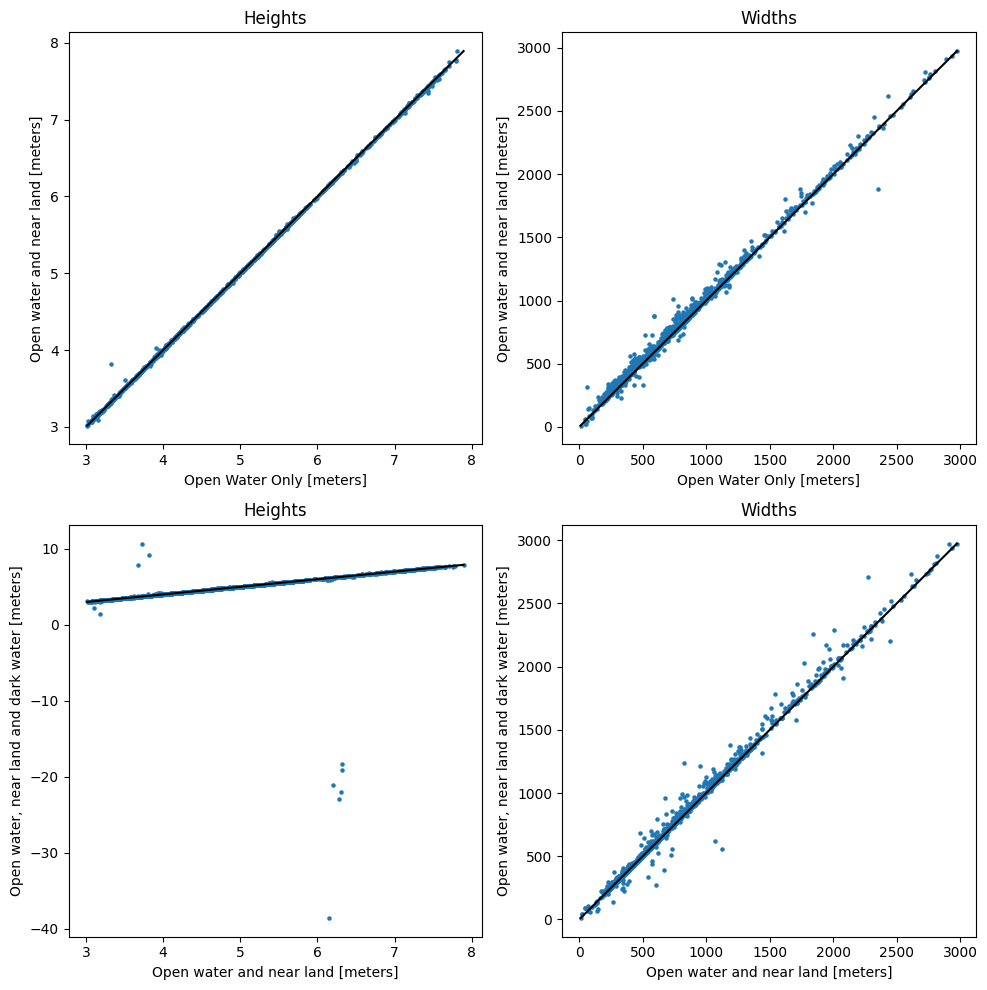

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

ax = axes[0, 0]
y1 = df.height_ow.values
y2 = df.height_wnl.values
ax.scatter(y1, y2, s=5)
combined_vals = np.concatenate([y1, y2])
eval_range = np.min(combined_vals), np.max(combined_vals)
height_eval_array = np.linspace(eval_range[0], eval_range[1], num=200)
ax.plot(height_eval_array, height_eval_array, color='black')
ax.set(title="Heights", xlabel='Open Water Only [meters]', ylabel='Open water and near land [meters]')

y = y2 - y1
mean_y = np.mean(y)
med_y = np.median(y)
std_y = np.std(y)
print("\nHeight Sensitivity [OW & WNL] - OW")
print(f"Mean Difference: {mean_y:0.3}")
print(f"Median Difference: {med_y:0.3}")
print(f"Std. Difference: {std_y:0.3}")
print(f"RMSE: {rmse(df.height_ow.values, df.height_wnl.values):0.3}")

ax = axes[0, 1]
y1 = df.width_ow.values
y2 = df.width_wnl.values
ax.scatter(y1, y2, s=5)
combined_vals = np.concatenate([y1, y2])
eval_range = np.min(combined_vals), np.max(combined_vals)
width_eval_array = np.linspace(eval_range[0], eval_range[1], num=200)
ax.plot(width_eval_array, width_eval_array, color='black')
ax.set(title="Widths", xlabel='Open Water Only [meters]', ylabel='Open water and near land [meters]')

y = y2 - y1
mean_y = np.mean(y)
med_y = np.median(y)
std_y = np.std(y)
print("\nWidth Sensitivity [OW & WNL] - OW")
print(f"Mean Difference: {mean_y:0.3}")
print(f"Median Difference: {med_y:0.3}")
print(f"Std. Difference: {std_y:0.3}")
print(f"RMSE: {rmse(df.width_ow.values, df.width_wnl.values):0.3}")

ax = axes[1, 0]
y1 = df.height_wnl.values
y2 = df.height_dw.values
ax.scatter(y1, y2, s=5)
ax.plot(height_eval_array, height_eval_array, color='black')
ax.set(title="Heights", xlabel='Open water and near land [meters]', ylabel='Open water, near land and dark water [meters]')

y = y2 - y1
mean_y = np.mean(y)
med_y = np.median(y)
std_y = np.std(y)
print("\nHeight Sensitivity [OW & WNL & DW] - [OW & WNL]")
print(f"Mean Difference: {mean_y:0.3}")
print(f"Median Difference: {med_y:0.3}")
print(f"Std. Difference: {std_y:0.3}")
print(f"RMSE: {rmse(df.height_wnl.values, df.height_dw.values):0.3}")

ax = axes[1, 1]
y1 = df.width_wnl.values
y2 = df.width_dw.values
ax.scatter(y1, y2, s=5)
ax.plot(width_eval_array, width_eval_array, color='black')
ax.set(title="Widths", xlabel='Open water and near land [meters]', ylabel='Open water, near land and dark water [meters]')

y = y2 - y1
mean_y = np.mean(y)
med_y = np.median(y)
std_y = np.std(y)
print("\nWidth Sensitivity [OW & WNL & DW] - [OW & WNL]")
print(f"Mean Difference: {mean_y:0.3}")
print(f"Median Difference: {med_y:0.3}")
print(f"Std. Difference: {std_y:0.3}")
print(f"RMSE: {rmse(df.width_wnl.values, df.width_dw.values):0.3}")


plt.tight_layout()
plt.show()